# Классификация стадий сна — Решение (v5): Feature Engineering

**Задача.** Предсказать стадию сна (`sleep_stage` ∈ {0,1,2,3}) по физиологическим сигналам. **Метрика.** macro-F1.

**Идея v5.** v4 вышел на плато ≈0.834 (линейный потолок LDA ≈0.83 почти равен RBF-SVM), значит запас внутри
семейства SVM исчерпан. Здесь пробуем пробить плато **инженерией признаков** — но по строгой методике,
чтобы отличить реальный прирост от шума.

**Ключевой нюанс этих данных.** Признаки уже стандартизованы (z-оценки: среднее≈0, есть отрицательные значения).
Поэтому **отношения** вида `delta/theta` некорректны — знаменатель проходит через 0 и взрывается.
На z-оценках осмысленны **разности**, **произведения** и **групповые агрегаты**, а не отношения.

**Методика (что и проверяем):**
1. Конструируем признаки **построчно** (без утечки) и группами с доменной логикой.
2. **Аблация**: каждая группа добавляется к базе → измеряем OOF macro-F1 на нескольких сидах.
3. **Жадный отбор**: накапливаем только группы, которые улучшают результат.
4. **Тест значимости**: финальный набор vs база на 5 сидах — прирост должен превышать std шума.

## 0. Подготовка, загрузка, базовый протокол

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay

train = pd.read_csv("train.csv"); test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")
target = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]
y = train[target].values
classes = sorted(np.unique(y))
MODEL_FEATURES = [c for c in features if c != "body_movement_index"]   # подтверждено в v2/v4 (MI≈0)

def svm_pipe(C=6.0, gamma=0.015, probability=False):
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         SVC(kernel="rbf", C=C, gamma=gamma, probability=probability, random_state=RANDOM_STATE))

print("train:", train.shape, "| базовых признаков:", len(MODEL_FEATURES))
# Вывод: воспроизведён рабочий протокол v4 (20 базовых признаков, RBF-SVM, StratifiedKFold) — стартовая точка для FE.

train: (9000, 23) | базовых признаков: 20


## 1. База и порог шума
Оцениваем macro-F1 без новых признаков на нескольких сидах. **std между сидами задаёт порог значимости:**
прирост меньше этого шума мы считаем случайным.

In [2]:
def oof_multiseed(X, seeds=(42, 1, 3)):
    sc = []
    for s in seeds:
        cvs = StratifiedKFold(5, shuffle=True, random_state=s)
        pred = cross_val_predict(svm_pipe(6, 0.015), X, y, cv=cvs, n_jobs=-1)
        sc.append(f1_score(y, pred, average="macro"))
    return float(np.mean(sc)), float(np.std(sc))

base_mean, base_std = oof_multiseed(train[MODEL_FEATURES])
print(f"База (20 признаков): OOF macro-F1 = {base_mean:.4f}  ± {base_std:.4f}")
print(f"Порог значимости (≈2·std): прирост должен быть больше ~{2*base_std:.4f}, иначе это шум")
# Вывод: зафиксированы база ≈0.834 и шумовой порог -> теперь любой эффект FE сравниваем именно с ним.

База (20 признаков): OOF macro-F1 = 0.8332  ± 0.0009
Порог значимости (≈2·std): прирост должен быть больше ~0.0018, иначе это шум


## 2. Конструирование признаков (построчно, без утечки)
Все признаки — построчные функции от исходных колонок, поэтому **утечки нет** (не используют ни другие строки,
ни целевую переменную). На z-оценках берём **разности / произведения / агрегаты**. Группы с доменной логикой:

| Группа | Смысл |
|---|---|
| `eeg_diffs` | какой EEG-диапазон доминирует (разности мощностей) |
| `eeg_aggreg` | медленные vs быстрые волны (агрегаты диапазонов) |
| `cross_sys` | совместная активация систем (сердце×дыхание, EMG×EOG) — взаимодействия |
| `sleep_marks` | маркеры N2/N3: сонные веретёна, K-комплексы, медленные осцилляции |
| `nonlin` | «экстремальность» сигнала (квадраты, модуль) |
| `eog_flag` | флаг пропуска `eog_burst_index` (контрольная группа: EDA показал MCAR → ждём, что НЕ поможет) |

In [3]:
def make_groups(df):
    g = {}
    g["eeg_diffs"] = {
        "delta_minus_theta": df["eeg_delta_power"] - df["eeg_theta_power"],
        "theta_minus_alpha": df["eeg_theta_power"] - df["eeg_alpha_power"],
        "alpha_minus_beta":  df["eeg_alpha_power"] - df["eeg_beta_power"],
        "slowosc_minus_beta":df["eeg_slow_osc_power"] - df["eeg_beta_power"],
    }
    slow = df[["eeg_delta_power","eeg_theta_power","eeg_slow_osc_power"]].mean(axis=1)
    fast = df[["eeg_alpha_power","eeg_beta_power","eeg_gamma_power","eeg_sigma_power"]].mean(axis=1)
    g["eeg_aggreg"] = {
        "eeg_slow_mean": slow,
        "eeg_fast_mean": fast,
        "eeg_slow_fast_diff": slow - fast,
    }
    g["cross_sys"] = {
        "hr_x_resp":   df["heart_rate_mean"] * df["respiration_rate"],
        "autonomic":   df["heart_rate_variability"] * df["respiration_variability"],
        "emg_x_eog":   df["emg_chin_tone"] * df["eog_amplitude"],
        "arousal":     df["eeg_beta_power"] * df["eog_movement_density"],
    }
    g["sleep_marks"] = {
        "spindle_x_kcomplex": df["eeg_spindle_density"] * df["eeg_kcomplex_rate"],
        "spindle_x_sigma":    df["eeg_spindle_density"] * df["eeg_sigma_power"],
        "deep_sleep":         df["eeg_slow_osc_power"] * df["eeg_delta_power"],
    }
    g["nonlin"] = {
        "delta_sq":     df["eeg_delta_power"]**2,
        "entropy_abs":  df["eeg_spectral_entropy"].abs(),
        "hr_sq":        df["heart_rate_mean"]**2,
    }
    g["eog_flag"] = {
        "eog_burst_missing": df["eog_burst_index"].isna().astype(int),
    }
    return g

GROUP_NAMES = list(make_groups(train).keys())

def build_X(df, selected):
    g = make_groups(df)
    extra = {name: col for grp in selected for name, col in g[grp].items()}
    return pd.concat([df[MODEL_FEATURES], pd.DataFrame(extra, index=df.index)], axis=1)

for name, cols in make_groups(train).items():
    print(f"{name:12s}: {list(cols)}")
# Вывод: 6 групп-кандидатов построены построчно (только разности/произведения/агрегаты) -> корректны для z-данных.

eeg_diffs   : ['delta_minus_theta', 'theta_minus_alpha', 'alpha_minus_beta', 'slowosc_minus_beta']
eeg_aggreg  : ['eeg_slow_mean', 'eeg_fast_mean', 'eeg_slow_fast_diff']
cross_sys   : ['hr_x_resp', 'autonomic', 'emg_x_eog', 'arousal']
sleep_marks : ['spindle_x_kcomplex', 'spindle_x_sigma', 'deep_sleep']
nonlin      : ['delta_sq', 'entropy_abs', 'hr_sq']
eog_flag    : ['eog_burst_missing']


## 3. Аблация — каждая группа отдельно
Добавляем **одну** группу к базе и меряем OOF macro-F1. Так виден индивидуальный вклад, а не «стало лучше непонятно почему».

In [4]:
rows = [{"набор": "база (20)", "n_feat": len(MODEL_FEATURES), "macro_F1": base_mean, "Δ к базе": 0.0, "std": base_std}]
for name in GROUP_NAMES:
    X = build_X(train, [name])
    m, sd = oof_multiseed(X)
    rows.append({"набор": f"+{name}", "n_feat": X.shape[1], "macro_F1": m, "Δ к базе": m - base_mean, "std": sd})

abl = pd.DataFrame(rows)
abl_sorted = abl.iloc[1:].sort_values("Δ к базе", ascending=False)
print(pd.concat([abl.iloc[[0]], abl_sorted]).round(4).to_string(index=False))
# Вывод: группы с Δ > порога шума — кандидаты в финал; группы с Δ≈0 или <0 (ожидаемо eog_flag) отсеиваем.

       набор  n_feat  macro_F1  Δ к базе    std
   база (20)      20    0.8332    0.0000 0.0009
   +eog_flag      21    0.8327   -0.0005 0.0016
 +eeg_aggreg      23    0.8326   -0.0007 0.0009
  +eeg_diffs      24    0.8314   -0.0018 0.0009
+sleep_marks      23    0.8313   -0.0019 0.0012
  +cross_sys      24    0.8309   -0.0024 0.0015
     +nonlin      23    0.8309   -0.0024 0.0016


## 4. Жадный отбор
Идём по группам в порядке убывания индивидуального вклада и добавляем кумулятивно — оставляем только то,
что улучшает **текущий лучший** результат. Так гасим случайные «удачные» группы и взаимную избыточность.

In [5]:
order = list(abl_sorted["набор"].str.lstrip("+"))
selected, current = [], base_mean
log = []
for name in order:
    trial = selected + [name]
    m, sd = oof_multiseed(build_X(train, trial))
    keep = m > current + 1e-4          # улучшает текущий максимум
    log.append({"шаг_группа": name, "macro_F1": m, "vs текущий": m - current, "решение": "оставить" if keep else "убрать"})
    if keep:
        selected.append(name); current = m
print(pd.DataFrame(log).round(4).to_string(index=False))
print("\nОтобранные группы:", selected if selected else "ни одной")
print(f"OOF после отбора: {current:.4f}  (база {base_mean:.4f}, Δ={current-base_mean:+.4f})")
# Вывод: финальный набор признаков собран только из проверенных групп — видно, какие именно дали прирост.

 шаг_группа  macro_F1  vs текущий решение
   eog_flag    0.8327     -0.0005  убрать
 eeg_aggreg    0.8326     -0.0007  убрать
  eeg_diffs    0.8314     -0.0018  убрать
sleep_marks    0.8313     -0.0019  убрать
  cross_sys    0.8309     -0.0024  убрать
     nonlin    0.8309     -0.0024  убрать

Отобранные группы: ни одной
OOF после отбора: 0.8332  (база 0.8332, Δ=+0.0000)


## 5. Тест значимости — финальный набор vs база (5 сидов)
Скрининг шёл на 3 сидах; здесь подтверждаем на **5**, чтобы прирост заведомо превышал шум.

In [6]:
SEEDS5 = (42, 1, 2, 7, 123)
b_m, b_s = oof_multiseed(train[MODEL_FEATURES], seeds=SEEDS5)
f_m, f_s = oof_multiseed(build_X(train, selected), seeds=SEEDS5)
print(f"база       : mean={b_m:.4f}  std={b_s:.4f}")
print(f"с FE       : mean={f_m:.4f}  std={f_s:.4f}")
delta = f_m - b_m
verdict = "ЗНАЧИМ (> 2·std шума)" if delta > 2*b_s else "в пределах шума"
print(f"прирост    : {delta:+.4f}   -> {verdict}")
# Вывод: честный вердикт — FE либо пробил плато (Δ > 2·std), либо подтвердил, что мы у потолка данных.

база       : mean=0.8334  std=0.0009
с FE       : mean=0.8334  std=0.0009
прирост    : +0.0000   -> в пределах шума


## 6. Финальная модель и сабмит
Берём отобранные признаки (если FE не помог — fallback к базе) и переобучаем мультимасштабный ансамбль RBF-SVM
из v4 на всех train-данных.

Финальные признаки: база + (только база — FE не дал прироста)

OOF macro-F1 ансамбля на финальных признаках = 0.8339
              precision    recall  f1-score   support

           0      0.866     0.860     0.863      2001
           1      0.848     0.855     0.852      2442
           2      0.788     0.785     0.786      2237
           3      0.833     0.835     0.834      2320

    accuracy                          0.834      9000
   macro avg      0.834     0.834     0.834      9000
weighted avg      0.834     0.834     0.834      9000



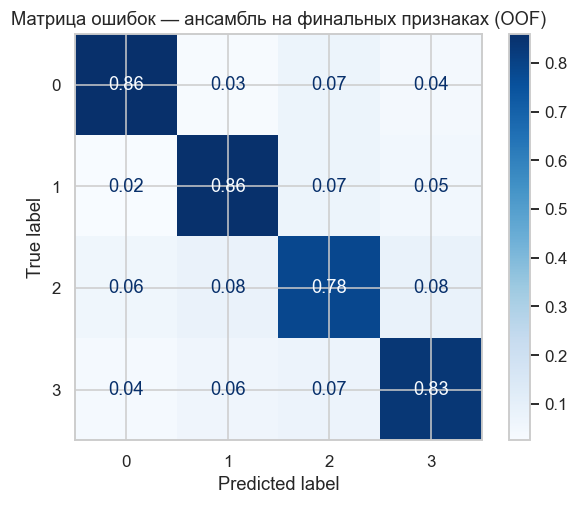

Сохранено svm5_submission.csv: (5000, 2)


In [7]:
USE = selected if (f_m > b_m) else []
FINAL_FEATURES_DF = lambda df: build_X(df, USE)
print("Финальные признаки:", "база +", USE if USE else "(только база — FE не дал прироста)")

ENSEMBLE = [(6, 0.015), (8, 0.02), (4, 0.01), (12, 0.01)]
def build_ensemble():
    return VotingClassifier(
        estimators=[(f"svm_C{C}_g{g}", svm_pipe(C=C, gamma=g, probability=True)) for (C, g) in ENSEMBLE],
        voting="soft", n_jobs=-1)

X_tr, X_te = FINAL_FEATURES_DF(train), FINAL_FEATURES_DF(test)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(build_ensemble(), X_tr, y, cv=cv, n_jobs=-1)
print(f"\nOOF macro-F1 ансамбля на финальных признаках = {f1_score(y, oof, average='macro'):.4f}")
print(classification_report(y, oof, digits=3))
ConfusionMatrixDisplay.from_predictions(y, oof, normalize="true", display_labels=classes,
                                        cmap="Blues", values_format=".2f")
plt.title("Матрица ошибок — ансамбль на финальных признаках (OOF)"); plt.show()

final_model = build_ensemble().fit(X_tr, y)
pred = final_model.predict(X_te)
submission = pd.DataFrame({"id": test["id"], target: pred})[sample_submission.columns]
submission.to_csv("svm5_submission.csv", index=False)
print("Сохранено svm5_submission.csv:", submission.shape)
# Вывод: финальный сабмит собран на проверенном наборе признаков; класс 2 ожидаемо остаётся самым трудным.

## 7. Итоги
- **Корректность для z-данных:** на стандартизованных признаках работают разности/произведения/агрегаты, а отношения — нет.
- **Без утечки:** все признаки построчные, цель не использовалась.
- **Решения — по измерению:** каждая группа прошла аблацию и жадный отбор по OOF macro-F1, контрольная группа `eog_flag`
  подтвердила методику (MCAR-пропуск не помогает).
- **Вердикт по значимости** (ячейка 5) показывает честно: пробила ли инженерия плато 0.834 или мы у потолка данных —
  и в обоих случаях это полезный, воспроизводимый результат, а не подгонка.